In [1]:
from scipy import sparse
import os
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

adata = ad.read_h5ad("../data_processed/main_qc_pca.h5ad")

In [2]:
adata.obs[:5]

,age,cell,cell_ontology_class,cell_ontology_id,free_annotation,method,mouse.id,n_genes,sex,subtissue,...,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,outlier,mt_outlier,scDblFinder_score,scDblFinder_class,leiden_res0_5,major_cell_type
index,,,,,,,,,,,,,,,,,,,,,
AAAGTAGTCTCATTCA-1-6-0-0,18m,MACA_18m_F_GAT_50_AAAGTAGTCTCATTCA,endothelial cell,NA,Cd36+,droplet,18-F-50,1240.0,female,Gat,...,0.0,749.0,6.620073,23.861103,False,False,0.004863,singlet,0,endothelial
AACTCAGGTTGGTGGA-1-6-0-0,18m,MACA_18m_F_GAT_50_AACTCAGGTTGGTGGA,mesenchymal stem cell of adipose,NA,nan,droplet,18-F-50,1189.0,female,Gat,...,0.0,720.0,6.580639,26.966291,False,False,0.010162,singlet,6,fibroblast/stromal
AACTTTCAGGAGCGAG-1-6-0-0,18m,MACA_18m_F_GAT_50_AACTTTCAGGAGCGAG,endothelial cell,NA,Cd36+,droplet,18-F-50,2985.0,female,Gat,...,0.0,1250.0,7.131699,13.563368,False,False,0.074011,singlet,9,endothelial
AACTTTCCAAGGGTCA-1-6-0-0,18m,MACA_18m_F_GAT_50_AACTTTCCAAGGGTCA,mesenchymal stem cell of adipose,NA,Cd34+,droplet,18-F-50,2956.0,female,Gat,...,0.0,2861.0,7.959276,23.560900,False,False,0.004138,singlet,6,fibroblast/stromal
AAGGCAGGTGCACGAA-1-6-0-0,18m,MACA_18m_F_GAT_50_AAGGCAGGTGCACGAA,endothelial cell,NA,Cd36+,droplet,18-F-50,2605.0,female,Gat,...,0.0,1804.0,7.498316,22.059183,False,False,0.023637,singlet,0,endothelial


In [3]:
X_counts = adata.layers["counts"]

In [4]:
meta = adata.obs[["mouse.id","tissue","major_cell_type","age_months","sex"]].copy()

meta.head()

,mouse.id,tissue,major_cell_type,age_months,sex
index,,,,,
AAAGTAGTCTCATTCA-1-6-0-0,18-F-50,Fat,endothelial,18.0,female
AACTCAGGTTGGTGGA-1-6-0-0,18-F-50,Fat,fibroblast/stromal,18.0,female
AACTTTCAGGAGCGAG-1-6-0-0,18-F-50,Fat,endothelial,18.0,female
AACTTTCCAAGGGTCA-1-6-0-0,18-F-50,Fat,fibroblast/stromal,18.0,female
AAGGCAGGTGCACGAA-1-6-0-0,18-F-50,Fat,endothelial,18.0,female


In [5]:
meta = adata.obs[["mouse.id","tissue","major_cell_type","age_months","sex"]].copy()

meta["sample_id"] = (meta["mouse.id"].astype(str)+ "_"+ meta["tissue"].astype(str)+ "_"+ meta["major_cell_type"].astype(str))

# 关键：生成整数索引
meta["cell_index"] = np.arange(adata.n_obs)

In [6]:
genes = adata.var_names

In [7]:
if sparse.issparse(X_counts):
    X_counts = X_counts.tocsr()
else:
    X_counts = sparse.csr_matrix(X_counts)

In [8]:
pb_counts = []
sample_names = []

for sample, group in meta.groupby("sample_id"):

    idx = group["cell_index"].values

    counts = X_counts[idx].sum(axis=0)

    counts = np.asarray(counts).ravel()

    pb_counts.append(counts)
    sample_names.append(sample)

pb_counts = np.vstack(pb_counts)

In [9]:
pseudobulk_counts = pd.DataFrame(pb_counts.T,index=genes,columns=sample_names)

pseudobulk_counts.head()

,1-M-62_Kidney_endothelial,1-M-62_Kidney_fibroblast/stromal,1-M-62_Liver_endothelial,1-M-62_Liver_fibroblast/stromal,1-M-62_Lung_endothelial,1-M-62_Lung_fibroblast/stromal,1-M-63_Heart_and_Aorta_endothelial,1-M-63_Heart_and_Aorta_fibroblast/stromal,1-M-63_Kidney_endothelial,1-M-63_Kidney_fibroblast/stromal,...,30-M-4_Lung_endothelial,30-M-4_Lung_fibroblast/stromal,30-M-5_Fat_endothelial,30-M-5_Fat_fibroblast/stromal,30-M-5_Kidney_endothelial,30-M-5_Kidney_fibroblast/stromal,30-M-5_Liver_endothelial,30-M-5_Liver_fibroblast/stromal,30-M-5_Lung_endothelial,30-M-5_Lung_fibroblast/stromal
index,,,,,,,,,,,,,,,,,,,,,
Sox17,359.0,4.0,11.0,0.0,2.0,1.0,540.0,6.0,509.0,9.0,...,27.0,1.0,955.0,11.0,167.0,16.0,29.0,0.0,3.0,0.0
Prex2,59.0,2.0,9.0,0.0,2.0,68.0,238.0,53.0,47.0,12.0,...,30.0,43.0,390.0,70.0,19.0,2.0,94.0,1.0,6.0,28.0
Msc,0.0,0.0,0.0,0.0,0.0,5.0,1.0,66.0,0.0,0.0,...,0.0,1.0,1.0,78.0,0.0,0.0,0.0,0.0,0.0,0.0
Gm106,0.0,1.0,0.0,0.0,0.0,4.0,4.0,2.0,0.0,3.0,...,0.0,0.0,21.0,24.0,0.0,0.0,0.0,0.0,0.0,0.0
Rpl7,1179.0,522.0,91.0,2.0,159.0,472.0,4055.0,3928.0,1271.0,434.0,...,238.0,87.0,6623.0,10132.0,416.0,90.0,763.0,39.0,70.0,95.0


In [10]:
os.makedirs("../data_processed",exist_ok=True)

pseudobulk_counts.to_csv("../data_processed/pseudobulk_counts.tsv",sep="\t")

In [11]:
pseudobulk_meta = (meta.drop_duplicates("sample_id").set_index("sample_id"))

pseudobulk_meta.head()

,mouse.id,tissue,major_cell_type,age_months,sex,cell_index
sample_id,,,,,,
18-F-50_Fat_endothelial,18-F-50,Fat,endothelial,18.0,female,0
18-F-50_Fat_fibroblast/stromal,18-F-50,Fat,fibroblast/stromal,18.0,female,1
18-M-52_Fat_endothelial,18-M-52,Fat,endothelial,18.0,male,583
18-M-52_Fat_fibroblast/stromal,18-M-52,Fat,fibroblast/stromal,18.0,male,584
18-M-53_Fat_fibroblast/stromal,18-M-53,Fat,fibroblast/stromal,18.0,male,1090


In [12]:
pseudobulk_meta.to_csv("../data_processed/pseudobulk_metadata.tsv",sep="\t")

In [13]:
library_qc = (meta.groupby("sample_id").size().to_frame("n_cells"))

In [14]:
library_qc["library_size"] = (pseudobulk_counts.sum(axis=0))

In [15]:
library_qc.head()

,n_cells,library_size
sample_id,,
1-M-62_Kidney_endothelial,138,412961.0
1-M-62_Kidney_fibroblast/stromal,49,167676.0
1-M-62_Liver_endothelial,25,54100.0
1-M-62_Liver_fibroblast/stromal,1,1995.0
1-M-62_Lung_endothelial,13,37661.0


In [16]:
library_qc = library_qc.join(pseudobulk_meta[["mouse.id","tissue","major_cell_type","age_months"]])

In [17]:
os.makedirs("../results/pseudobulk",exist_ok=True)

library_qc.to_csv("../results/pseudobulk/library_qc.csv")

In [18]:
import random

test_samples = random.sample(list(meta["sample_id"].unique()),5)

for sample in test_samples:
    idx = meta.loc[meta["sample_id"] == sample,"cell_index"]
    direct_sum = np.asarray(X_counts[idx].sum(axis=0)).ravel()
    saved_sum = pseudobulk_counts[sample].values
    print(sample,np.array_equal(direct_sum,saved_sum))

18-F-51_Liver_fibroblast/stromal True
3-M-9_Kidney_fibroblast/stromal True
18-F-50_Lung_fibroblast/stromal True
21-F-55_Kidney_fibroblast/stromal True
21-F-55_Lung_fibroblast/stromal True


In [19]:
# ==================== 组内样本相关性分析 ====================
# pseudobulk sample_id 已由 mouse.id + tissue + major_cell_type 构成。
# 因此样本相关性应在相同 tissue × major_cell_type 内比较，避免把真实的组织/细胞类型差异误判为离群。

# 对 pseudobulk counts 做 log1p 变换后计算 Pearson correlation
pseudobulk_log = np.log1p(pseudobulk_counts)

# 保存每个 tissue × cell type 的相关性矩阵和样本平均相关性
corr_matrices = {}
mean_corr_all = pd.Series(index=pseudobulk_counts.columns, dtype=float)

for (tissue, cell_type), group_meta in pseudobulk_meta.groupby(["tissue", "major_cell_type"]):
    samples = group_meta.index.intersection(pseudobulk_log.columns)
    if len(samples) < 2:
        continue

    corr_group = pseudobulk_log.loc[:, samples].corr(method="pearson")
    corr_matrices[(tissue, cell_type)] = corr_group

    # 每个样本与同组其它样本的平均相关性（排除自身）
    corr_no_self = corr_group.copy()
    np.fill_diagonal(corr_no_self.values, np.nan)
    mean_corr_all.loc[samples] = corr_no_self.mean(axis=1)

library_qc["mean_sample_correlation"] = mean_corr_all.reindex(library_qc.index)

# 保存所有组内相关性矩阵
os.makedirs("../results/pseudobulk/correlation", exist_ok=True)
for (tissue, cell_type), corr_group in corr_matrices.items():
    safe_tissue = str(tissue).replace("/", "_").replace(" ", "_")
    safe_cell = str(cell_type).replace("/", "_").replace(" ", "_")
    corr_group.to_csv(
        f"../results/pseudobulk/correlation/{safe_tissue}__{safe_cell}__correlation.csv"
    )

print(f"共计算 {len(corr_matrices)} 个 tissue × cell type 组的样本相关性")
library_qc[["mean_sample_correlation", "tissue", "major_cell_type"]].head()

共计算 10 个 tissue × cell type 组的样本相关性


C:\Users\asd123cheese\AppData\Local\Temp\ipykernel_21992\1312896747.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for (tissue, cell_type), group_meta in pseudobulk_meta.groupby(["tissue", "major_cell_type"]):


,mean_sample_correlation,tissue,major_cell_type
sample_id,,,
1-M-62_Kidney_endothelial,0.961972,Kidney,endothelial
1-M-62_Kidney_fibroblast/stromal,0.904782,Kidney,fibroblast/stromal
1-M-62_Liver_endothelial,0.874005,Liver,endothelial
1-M-62_Liver_fibroblast/stromal,0.731870,Liver,fibroblast/stromal
1-M-62_Lung_endothelial,0.927299,Lung,endothelial


In [20]:
# ==================== 组内样本级离群检测：最终规则 ====================
# 最终规则：
# 1) 明确将 30-M-2 × Lung × fibroblast/stromal 标记为离群；
# 2) 其他所有 n_cells < 3 的样本标记为离群；
# 3) 不再因为相关性 0.8–0.9、library size MAD 或 correlation MAD 自动判定离群。
#
# sample_outlier 只是“标记”，不会删除原始 pseudobulk_counts。

library_qc["low_cell_count_lt3"] = library_qc["n_cells"] < 3

library_qc["is_30M2_Lung_fibroblast"] = (
    library_qc["mouse.id"].astype(str).eq("30-M-2")
    & library_qc["tissue"].astype(str).eq("Lung")
    & library_qc["major_cell_type"].astype(str).eq("fibroblast/stromal")
)

library_qc["sample_outlier"] = (
    library_qc["low_cell_count_lt3"]
    | library_qc["is_30M2_Lung_fibroblast"]
)

def get_outlier_reason(row):
    reasons = []
    if row["is_30M2_Lung_fibroblast"]:
        reasons.append("explicit_30M2_Lung_fibroblast")
    if row["low_cell_count_lt3"]:
        reasons.append("n_cells<3")
    return ";".join(reasons) if reasons else "None"

library_qc["outlier_reason"] = library_qc.apply(get_outlier_reason, axis=1)

sample_outliers = library_qc[library_qc["sample_outlier"]].copy()

print("样本总数:", len(library_qc))
print("最终标记为离群的样本数:", len(sample_outliers))
print("30-M-2 × Lung × fibroblast/stromal:", int(library_qc["is_30M2_Lung_fibroblast"].sum()))
print("n_cells < 3:", int(library_qc["low_cell_count_lt3"].sum()))

display_cols = [
    "mouse.id", "tissue", "major_cell_type", "age_months",
    "n_cells", "library_size", "mean_sample_correlation",
    "outlier_reason"
]
sample_outliers[display_cols]


样本总数: 110
最终标记为离群的样本数: 6
30-M-2 × Lung × fibroblast/stromal: 1
n_cells < 3: 6


,mouse.id,tissue,major_cell_type,age_months,n_cells,library_size,mean_sample_correlation,outlier_reason
sample_id,,,,,,,,
1-M-62_Liver_fibroblast/stromal,1-M-62,Liver,fibroblast/stromal,1.0,1,1995.0,0.731870,n_cells<3
18-F-51_Liver_fibroblast/stromal,18-F-51,Liver,fibroblast/stromal,18.0,2,11910.0,0.744053,n_cells<3
21-F-54_Liver_fibroblast/stromal,21-F-54,Liver,fibroblast/stromal,21.0,2,10875.0,0.823167,n_cells<3
24-M-58_Liver_endothelial,24-M-58,Liver,endothelial,24.0,2,3983.0,0.794317,n_cells<3
3-F-56_Liver_fibroblast/stromal,3-F-56,Liver,fibroblast/stromal,3.0,1,3473.0,0.765812,n_cells<3
30-M-2_Lung_fibroblast/stromal,30-M-2,Lung,fibroblast/stromal,30.0,2,5165.0,0.669371,explicit_30M2_Lung_fibroblast;n_cells<3


In [21]:
# ==================== 保存最终 sample-level QC 结果 ====================
os.makedirs("../results/pseudobulk", exist_ok=True)

library_qc.to_csv("../results/pseudobulk/library_qc.csv")
sample_outliers.to_csv("../results/pseudobulk/sample_outliers.csv")

print("已保存:")
print("../results/pseudobulk/library_qc.csv")
print("../results/pseudobulk/sample_outliers.csv")


已保存:
../results/pseudobulk/library_qc.csv
../results/pseudobulk/sample_outliers.csv


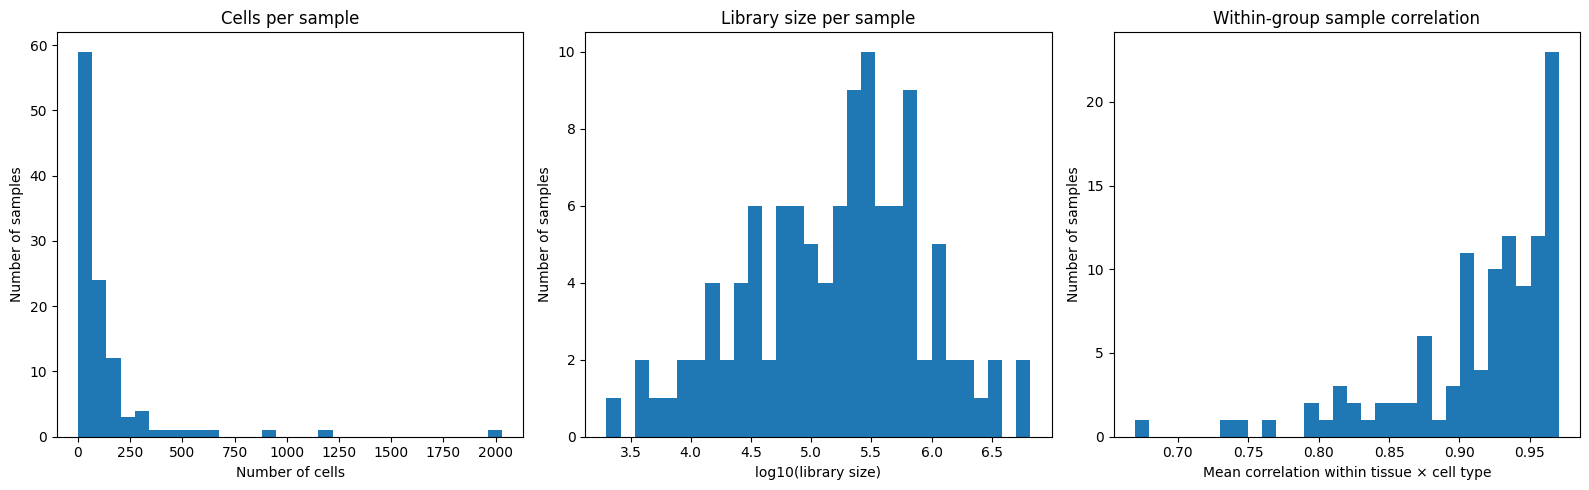

组内相关性热图已保存：../results/pseudobulk/sample_correlation_by_group.pdf
QC 分布图已保存：../results/pseudobulk/sample_QC_distributions.pdf


In [22]:
# ==================== QC 可视化：组内相关性热图 + QC 指标 ====================
from matplotlib.backends.backend_pdf import PdfPages

os.makedirs("../results/pseudobulk", exist_ok=True)

# 1. 每个 tissue × cell type 单独一页
with PdfPages("../results/pseudobulk/sample_correlation_by_group.pdf") as pdf:
    for (tissue, cell_type), corr_group in corr_matrices.items():
        n = len(corr_group)
        fig_size = max(5, min(12, 4 + n * 0.25))
        fig, ax = plt.subplots(figsize=(fig_size, fig_size))

        im = ax.imshow(
            corr_group,
            vmin=0,
            vmax=1,
            cmap="viridis",
            aspect="auto"
        )
        fig.colorbar(im, ax=ax, label="Pearson correlation")

        if n <= 25:
            ax.set_xticks(range(n))
            ax.set_yticks(range(n))
            ax.set_xticklabels(corr_group.columns, rotation=90, fontsize=7)
            ax.set_yticklabels(corr_group.index, fontsize=7)
        else:
            ax.set_xticks([])
            ax.set_yticks([])

        ax.set_title(
            f"{tissue} | {cell_type} | n={n}\n"
            "Pseudobulk sample correlation (log1p counts)"
        )

        plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

# 2. 三个主要 sample-level QC 指标分布
# 直接由 library_size 计算 log10，避免依赖某个前置 cell 是否已经运行。
log10_library_size = np.log10(
    pd.to_numeric(library_qc["library_size"], errors="coerce").clip(lower=1)
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(library_qc["n_cells"].dropna(), bins=30)
axes[0].set_xlabel("Number of cells")
axes[0].set_ylabel("Number of samples")
axes[0].set_title("Cells per sample")

axes[1].hist(log10_library_size.dropna(), bins=30)
axes[1].set_xlabel("log10(library size)")
axes[1].set_ylabel("Number of samples")
axes[1].set_title("Library size per sample")

axes[2].hist(library_qc["mean_sample_correlation"].dropna(), bins=30)
axes[2].set_xlabel("Mean correlation within tissue × cell type")
axes[2].set_ylabel("Number of samples")
axes[2].set_title("Within-group sample correlation")

plt.tight_layout()
plt.savefig("../results/pseudobulk/sample_QC_distributions.pdf")
plt.show()

print("组内相关性热图已保存：../results/pseudobulk/sample_correlation_by_group.pdf")
print("QC 分布图已保存：../results/pseudobulk/sample_QC_distributions.pdf")


In [23]:
# ==================== 排除离群样本后，使用 edgeR::filterByExpr 过滤低表达基因 ====================
# 原始 pseudobulk_counts 不修改。
# filterByExpr 使用保留下来的非离群样本，并按 tissue × major_cell_type 定义 group。
#
# 需要 R + edgeR。当前 Python 环境若没有 Rscript，只生成输入文件和 R 脚本，
# 不会用其他方法冒充 filterByExpr。

import subprocess
import shutil

filter_dir = "../results/pseudobulk/filterByExpr"
os.makedirs(filter_dir, exist_ok=True)

analysis_samples = library_qc.index[
    ~library_qc["sample_outlier"]
].tolist()

counts_for_filter = pseudobulk_counts.loc[:, analysis_samples].copy()

group_for_filter = (
    pseudobulk_meta.loc[analysis_samples, "tissue"].astype(str)
    + "__"
    + pseudobulk_meta.loc[analysis_samples, "major_cell_type"].astype(str)
)

counts_input = os.path.join(filter_dir, "counts_for_filterByExpr.tsv")
meta_input = os.path.join(filter_dir, "meta_for_filterByExpr.tsv")
filtered_file = os.path.join(filter_dir, "pseudobulk_counts_filterByExpr.tsv")
summary_file = os.path.join(filter_dir, "filterByExpr_gene_summary.tsv")
r_script_path = os.path.join(filter_dir, "run_filterByExpr.R")

counts_for_filter.to_csv(counts_input, sep="\t")
pd.DataFrame({
    "sample_id": analysis_samples,
    "group": group_for_filter.values
}).to_csv(meta_input, sep="\t", index=False)

r_code = r'''
suppressPackageStartupMessages(library(edgeR))

args <- commandArgs(trailingOnly = TRUE)

counts_file <- args[1]
meta_file <- args[2]
out_file <- args[3]
summary_file <- args[4]

counts <- as.matrix(read.table(
    counts_file,
    header = TRUE,
    row.names = 1,
    sep = "\t",
    check.names = FALSE
))

meta <- read.table(
    meta_file,
    header = TRUE,
    sep = "\t",
    stringsAsFactors = FALSE,
    check.names = FALSE
)

rownames(meta) <- meta$sample_id
meta <- meta[colnames(counts), , drop = FALSE]

y <- DGEList(counts = counts)
keep <- filterByExpr(y, group = factor(meta$group))

filtered_counts <- counts[keep, , drop = FALSE]

write.table(
    filtered_counts,
    file = out_file,
    sep = "\t",
    quote = FALSE,
    col.names = NA
)

gene_summary <- data.frame(
    gene = rownames(counts),
    keep_filterByExpr = keep,
    row.names = NULL,
    check.names = FALSE
)

write.table(
    gene_summary,
    file = summary_file,
    sep = "\t",
    quote = FALSE,
    row.names = FALSE
)

cat("Genes before:", nrow(counts), "\n")
cat("Genes kept:", sum(keep), "\n")
cat("Genes removed:", sum(!keep), "\n")
'''

with open(r_script_path, "w", encoding="utf-8") as f:
    f.write(r_code)

rscript = shutil.which("Rscript")

if rscript is None:
    print("当前 Python 环境未检测到 Rscript。")
    print("已准备好 filterByExpr 输入文件和 R 脚本：")
    print(r_script_path)
    print("安装 R + edgeR 后运行该 R 脚本即可。")
else:
    result = subprocess.run(
        [
            rscript,
            r_script_path,
            counts_input,
            meta_input,
            filtered_file,
            summary_file
        ],
        capture_output=True,
        text=True
    )

    print(result.stdout)

    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError("edgeR::filterByExpr 运行失败。")

    analysis_counts = pd.read_csv(
        filtered_file,
        sep="\t",
        index_col=0
    )

    print("filterByExpr 完成。")
    print("过滤前基因数:", pseudobulk_counts.shape[0])
    print("过滤后基因数:", analysis_counts.shape[0])
    print("下游分析样本数:", analysis_counts.shape[1])


Genes before: 3000 
Genes kept: 2161 
Genes removed: 839 

filterByExpr 完成。
过滤前基因数: 3000
过滤后基因数: 2161
下游分析样本数: 104


### 最终下游数据对象

- `pseudobulk_counts`：原始 pseudobulk counts，不修改。
- `sample_outliers`：最终标记的离群样本。
- `analysis_samples`：排除离群样本后的样本。
- `analysis_counts`：经 `edgeR::filterByExpr` 过滤低表达基因后的矩阵。

后续 PCA、聚类和差异表达分析优先使用 `analysis_counts`。
